# RateMyProfessor Analyzer
**Author:** Rayan Khan
**GitHub:** https://github.com/Rayan-K-Khan
**Date:** June 2026

In [63]:
!pip install requests beautifulsoup4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
import json
import base64
from collections import Counter
import statistics
from IPython.display import display, Markdown

#Search and Scrape

In [64]:
def search_professor(prof_name, school_name):
    url = "https://www.ratemyprofessors.com/graphql"

    headers = {
        "Authorization": "Basic dGVzdDp0ZXN0",
        "Content-Type": "application/json",
        "User-Agent": "Mozilla/5.0"
    }

    query = """
    query NewSearchTeachersQuery($query: TeacherSearchQuery!) {
      newSearch {
        teachers(query: $query, first: 10) {
          edges {
            node {
              id
              legacyId
              firstName
              lastName
              department
              school {
                name
                city
                state
              }
              avgRating
              numRatings
            }
          }
        }
      }
    }
    """

    payload = {
        "query": query,
        "variables": {
            "query": {
                "text": prof_name
            }
        }
    }

    response = requests.post(url, json=payload, headers=headers)
    teachers = response.json()["data"]["newSearch"]["teachers"]["edges"]

    filtered = [t for t in teachers if school_name.lower() in t["node"]["school"]["name"].lower()]

    if not filtered:
        print("No professors found at that school, showing all results:")
        filtered = teachers

    if not filtered:
        print("No professors found.")
        return None

    print("\nResults found:")
    for i, t in enumerate(filtered):
        node = t["node"]
        print(f"{i+1}. {node['firstName']} {node['lastName']} — {node['department']} at {node['school']['name']} ({node['school']['city']}, {node['school']['state']}) | Rating: {node['avgRating']}")

    choice = int(input("\nEnter the number of the correct professor: ")) - 1
    return filtered[choice]["node"]

In [65]:
prof_name = input("Enter professor name: ")
school_name = input("Enter school name: ")
result = search_professor(prof_name, school_name)
print(result)

Enter professor name: samaneh berenjian
Enter school name: njit
No professors found at that school, showing all results:

Results found:
1. Samaneh Berenjian — Computer Science at New Jersey Institute of Technology (Newark, NJ) | Rating: 4.3
2. Samaneh Samiee — Business at University of Texas at Arlington (Arlington, TX) | Rating: 4.8
3. Samaneh Gholami — Mathematics at Toronto Metropolitan University (Toronto, ON) | Rating: 2
4. Samaneh Eksir — Linguistics at University of South Carolina (Columbia, SC) | Rating: 5
5. Samaneh Ahmadinejad — Mechanical Engineering at Moraine Valley Community College (Palos Hills, IL) | Rating: 3
6. Samaneh Hashemi — Engineering at British Columbia Institute of Technology (Vancouver, BC) | Rating: 1.7
7. Samaneh Hamidi — Mathematics at Utah Valley University (, ) | Rating: 3.1
8. Samaneh Hamidi — Mathematics at University of Massachusetts - Boston (Boston, MA) | Rating: 2
9. Samaneh Fooladi — Engineering at University of Arizona (Tucson, AZ) | Rating: 3.7

In [66]:
def search_professor_silent(prof_name, school_name):
    """Non-interactive version of search_professor() - returns the best
    match automatically instead of prompting for input, so it can be
    called inside a loop for batch scraping."""
    url = "https://www.ratemyprofessors.com/graphql"
    headers = {
        "Authorization": "Basic dGVzdDp0ZXN0",
        "Content-Type": "application/json",
        "User-Agent": "Mozilla/5.0"
    }
    query = """
    query NewSearchTeachersQuery($query: TeacherSearchQuery!) {
      newSearch {
        teachers(query: $query, first: 10) {
          edges {
            node {
              id
              legacyId
              firstName
              lastName
              department
              school { name city state }
              avgRating
              numRatings
            }
          }
        }
      }
    }
    """
    payload = {"query": query, "variables": {"query": {"text": prof_name}}}
    response = requests.post(url, json=payload, headers=headers)
    teachers = response.json()["data"]["newSearch"]["teachers"]["edges"]

    filtered = [t for t in teachers if school_name.lower() in t["node"]["school"]["name"].lower()]
    if not filtered:
        return None  # no match at that school - skip rather than guess wrong

    # Pick the match with the most ratings (most reliable data), not just the first
    best = max(filtered, key=lambda t: t["node"]["numRatings"] or 0)
    return best["node"]

In [67]:
def safe_extract(pattern, text, default="0"):
    """Safely extracts a regex match. Returns default if no match or if value is null."""
    match = re.search(pattern, text)
    if match:
        val = match.group(1).strip()
        if val in ["null", "None", "", "null;"]:
            return default
        return val
    return default

def scrape_professor(url, prof_id):
    page = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    idx = page.text.find(f'\"legacyId\":{prof_id}')
    chunk = page.text[max(0, idx-50):idx+5000]
    professor = {
        "name": safe_extract(r'\"firstName\":\"(.*?)\"', chunk, "Unknown") + " " + safe_extract(r'\"lastName\":\"(.*?)\"', chunk, "Professor"),
        "department": safe_extract(r'\"department\":\"(.*?)\"', chunk, "Unknown"),
        "avg_rating": float(safe_extract(r'\"avgRating\":([^,}]*)', chunk, "0.0")),
        "avg_difficulty": float(safe_extract(r'\"avgDifficulty\":([^,}]*)', chunk, "0.0")),
        "num_ratings": int(safe_extract(r'\"numRatings\":([^,}]*)', chunk, "0")),
        "would_take_again": float(safe_extract(r'\"wouldTakeAgainPercent\":([^,}]*)', chunk, "0.0")),
        "ratings_distribution": {
            "1 star": int(safe_extract(r'\"r1\":([^,}]*)', chunk, "0")),
            "2 star": int(safe_extract(r'\"r2\":([^,}]*)', chunk, "0")),
            "3 star": int(safe_extract(r'\"r3\":([^,}]*)', chunk, "0")),
            "4 star": int(safe_extract(r'\"r4\":([^,}]*)', chunk, "0")),
            "5 star": int(safe_extract(r'\"r5\":([^,}]*)', chunk, "0")),
        }
    }

    encoded_id = base64.b64encode(f"Teacher-{prof_id}".encode()).decode()
    api_response = requests.post(
        "https://www.ratemyprofessors.com/graphql",
        headers={
            "Authorization": "Basic dGVzdDp0ZXN0",
            "Content-Type": "application/json",
            "User-Agent": "Mozilla/5.0",
            "Referer": url
        },
        json={
            "query": """
            query RatingsListQuery($id: ID!) {
              node(id: $id) {
                ... on Teacher {
                  ratings(first: 100) {
                    edges {
                      node {
                        date
                        class
                        comment
                        helpfulRating
                        difficultyRating
                        grade
                        wouldTakeAgain
                      }
                    }
                  }
                }
              }
            }
            """,
            "variables": {"id": encoded_id}
        }
    )

    try:
        res_json = api_response.json()
        node = res_json.get("data", {}).get("node", {})
        if node and "ratings" in node and node["ratings"]:
            edges = node["ratings"].get("edges", [])
        else:
            edges = []
    except Exception:
        edges = []

    reviews = [edge["node"] for edge in edges if edge and "node" in edge]
    return professor, reviews

#Load ratings and data setup

In [68]:
if result:
    numeric_id = result["legacyId"]
    rmp_url = f"https://www.ratemyprofessors.com/professor/{numeric_id}"
    professor, reviews = scrape_professor(rmp_url, numeric_id)
    all_comments = "\n".join([f"- {r['comment']}" for r in reviews if r['comment'].strip()])
    difficulty_ratings = [r["difficultyRating"] for r in reviews]
    print(f"Loaded: {professor['name']} — {professor['num_ratings']} ratings")

Loaded: Samaneh Berenjian — 87 ratings


#Difficulty Distribution

Total reviews: 87


/tmp/ipykernel_3116/536510898.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[1,2,3,4,5], y=[diff_counts.get(i, 0) for i in range(1,6)], palette=colors)


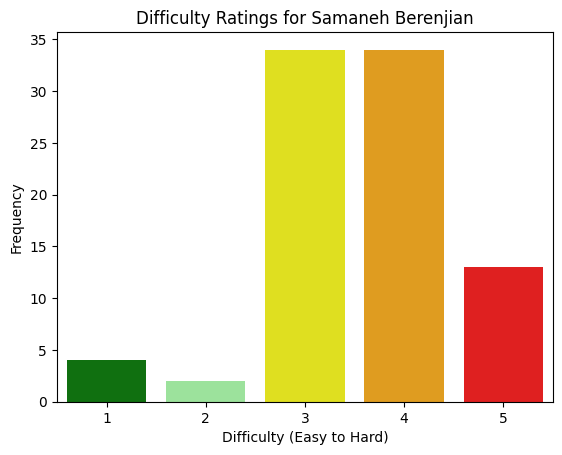

In [69]:
difficulty_ratings = [r["difficultyRating"] for r in reviews if r.get("difficultyRating") is not None]

print(f"Total reviews: {len(difficulty_ratings)}")

colors = ["green", "lightgreen", "yellow", "orange", "red"]

diff_counts = Counter(difficulty_ratings)
sns.barplot(x=[1,2,3,4,5], y=[diff_counts.get(i, 0) for i in range(1,6)], palette=colors)
plt.title(f"Difficulty Ratings for {professor['name']}")
plt.xlabel("Difficulty (Easy to Hard)")
plt.ylabel("Frequency")
plt.show()

#Quality Distribution

[12, 1, 3, 6, 65]


/tmp/ipykernel_3116/1014590944.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[1,2,3,4,5], y=ratings, palette=colors[::-1])


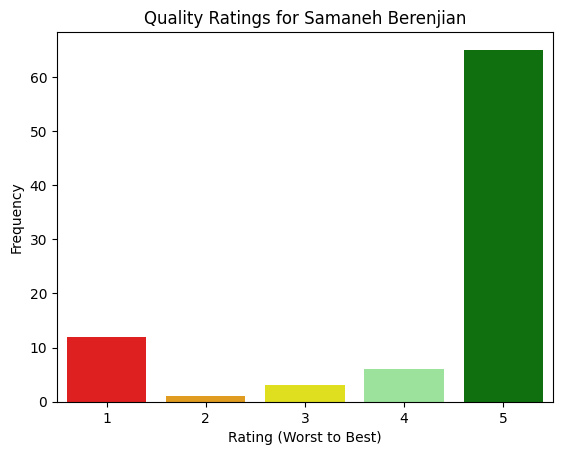

In [70]:
ratings = list(professor["ratings_distribution"].values())
print(ratings)

sns.barplot(x=[1,2,3,4,5], y=ratings, palette=colors[::-1])
plt.title(f'Quality Ratings for {professor["name"]}')
plt.xlabel('Rating (Worst to Best)')
plt.ylabel('Frequency')
plt.show()



In [71]:
courses = [r["class"] for r in reviews if r["class"].strip()]
course_counts = Counter(courses)
num_reviews = 0

print("Courses taught:")
for course, count in course_counts.most_common():
    print(f"  {course}: {count} reviews")
    num_reviews += count

print(f"\nTotal reviews: {num_reviews}")

Courses taught:
  cs356: 33 reviews
  CS656: 30 reviews
  CS696: 22 reviews
  CS351: 2 reviews

Total reviews: 87


#Courses taught

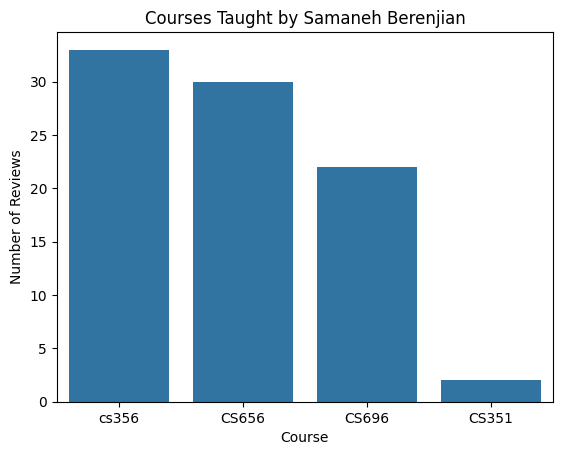

In [72]:
courses_sorted = course_counts.most_common()
course_names = [c[0] for c in courses_sorted]
course_review_counts = [c[1] for c in courses_sorted]

sns.barplot(x=course_names, y=course_review_counts)
plt.title(f"Courses Taught by {professor['name']}")
plt.xlabel("Course")
plt.ylabel("Number of Reviews")
plt.show()

#Overall letter grade distribution

/tmp/ipykernel_3116/2449816374.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=final_x_order, y=ordered_y_counts, ax=ax, palette=palette)


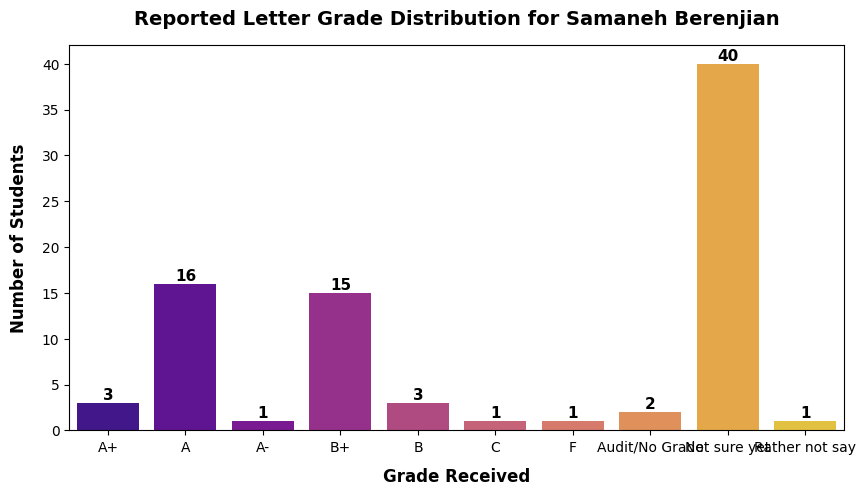

In [73]:
grade_list = [
    r["grade"].strip() for r in reviews
    if r.get("grade") and r["grade"].strip() not in ["", "N/A", "Select", "Not given"]
]

if not grade_list:
    display(Markdown("### Grade Distribution"))
    display(Markdown("*No student letter grades were submitted for this professor.*"))

else:
    grade_counts = Counter(grade_list)

    standard_order = ['A+', 'A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F', 'WD', 'INC']

    ordered_grades = [g for g in standard_order if g in grade_counts]

    extra_grades = sorted([g for g in grade_counts if g not in standard_order])
    final_x_order = ordered_grades + extra_grades

    ordered_y_counts = [grade_counts[g] for g in final_x_order]

    fig, ax = plt.subplots(figsize=(10, 5))

    palette = sns.color_palette("plasma", len(final_x_order))

    sns.barplot(x=final_x_order, y=ordered_y_counts, ax=ax, palette=palette)

    ax.set_title(f"Reported Letter Grade Distribution for {professor.get('name', 'Professor')}", fontsize=14, weight='bold', pad=15)
    ax.set_xlabel("Grade Received", fontsize=12, weight='bold', labelpad=10)
    ax.set_ylabel("Number of Students", fontsize=12, weight='bold', labelpad=10)

    ax.yaxis.get_major_locator().set_params(integer=True)

    for i, count in enumerate(ordered_y_counts):
        ax.text(i, count + 0.05, str(count), ha='center', va='bottom', fontsize=11, weight='bold')

    plt.show()

#Course-by-course letter grade distribution

/tmp/ipykernel_3116/1499701547.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=final_x_axis, y=final_y_counts, ax=ax, palette=sns.color_palette("viridis", len(final_x_axis)))
/tmp/ipykernel_3116/1499701547.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=final_x_axis, y=final_y_counts, ax=ax, palette=sns.color_palette("viridis", len(final_x_axis)))
/tmp/ipykernel_3116/1499701547.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=final_x_axis, y=final_y_counts, ax=ax, palette=sns.color_palette("viridis", len(final_x_axis)))
/

###Course-by-Course Grade Distribution Summary

Successfully generated a multi-panel visual grid tracking **4 unique courses**.

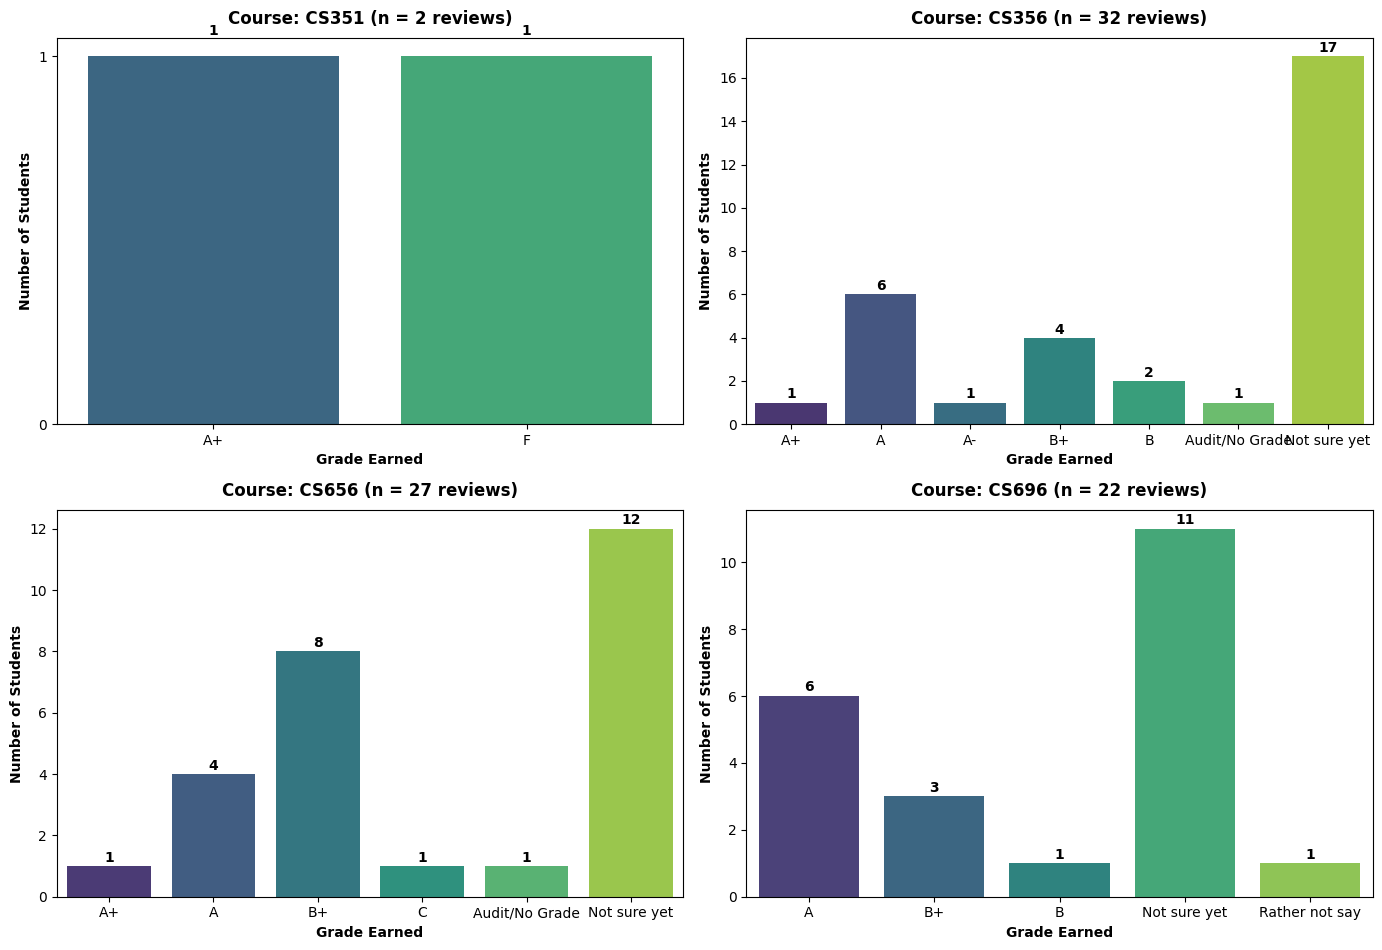

In [74]:
course_grade_data = []
for r in reviews:
    course_code = r.get("class", "").strip().upper()
    grade_received = r.get("grade", "").strip()

    invalid_tags = ["", "N/A", "Select", "Not given", "NONE"]
    if course_code and grade_received and grade_received not in invalid_tags:
        course_grade_data.append({"Course": course_code, "Grade": grade_received})

if not course_grade_data:
    display(Markdown("###Course-by-Course Grade Distribution"))
    display(Markdown("*No course-specific grade data is available for this professor.*"))

else:
    df = pd.DataFrame(course_grade_data)
    unique_courses = sorted(df["Course"].unique())
    num_courses = len(unique_courses)

    df_summary = df.groupby(["Course", "Grade"]).size().reset_index(name="Student Count")
    df_summary.to_csv("course_grade_summary.csv", index=False)

    standard_scale = ['A+', 'A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F', 'WD', 'INC']

    cols = 2 if num_courses > 1 else 1
    rows = (num_courses + 1) // 2 if num_courses > 1 else 1

    fig, axes = plt.subplots(rows, cols, figsize=(14, 4.8 * rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, course_title in enumerate(unique_courses):
        ax = axes_flat[idx]

        df_subset = df[df["Course"] == course_title]
        counts = df_subset["Grade"].value_counts()

        sorted_x = [g for g in standard_scale if g in counts]
        outlier_entries = sorted([g for g in counts.index if g not in standard_scale])
        final_x_axis = sorted_x + outlier_entries
        final_y_counts = [counts[g] for g in final_x_axis]

        sns.barplot(x=final_x_axis, y=final_y_counts, ax=ax, palette=sns.color_palette("viridis", len(final_x_axis)))

        ax.set_title(f"Course: {course_title} (n = {len(df_subset)} reviews)", fontsize=12, weight='bold', pad=10)
        ax.set_xlabel("Grade Earned", fontsize=10, weight='bold')
        ax.set_ylabel("Number of Students", fontsize=10, weight='bold')
        ax.yaxis.get_major_locator().set_params(integer=True)

        for i, val in enumerate(final_y_counts):
            ax.text(i, val + 0.05, str(val), ha='center', va='bottom', fontsize=10, weight='bold')

    for extra_idx in range(num_courses, len(axes_flat)):
        fig.delaxes(axes_flat[extra_idx])

    plt.tight_layout()

    plt.savefig('course_grade_distributions.png', bbox_inches='tight', dpi=300)

    display(Markdown("###Course-by-Course Grade Distribution Summary"))
    display(Markdown(f"Successfully generated a multi-panel visual grid tracking **{num_courses} unique courses**."))

#Retake percentage

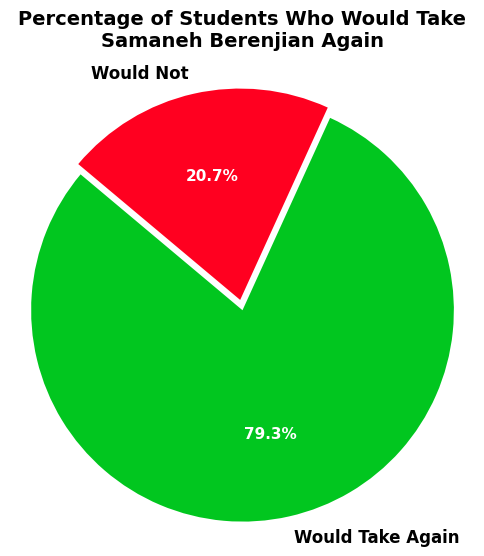

In [75]:
wta_percent = professor.get("would_take_again", 0.0)
count = professor.get("num_ratings", 0)

if count == 0:
    display(Markdown("###Retake Percentage Visualization"))
    display(Markdown("*No rating data available to display 'Would Take Again' percentage.*"))

else:
    labels = ['Would Take Again', 'Would Not']
    sizes = [wta_percent, max(0.0, 100.0 - wta_percent)]

    colors = ['#01c61f', '#ff0020']

    explode = (0.05, 0)
    plt.figure(figsize=(6, 6))

    patches, texts, autotexts = plt.pie(
        sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        textprops={'fontsize': 12}
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
        autotext.set_fontsize(11)

    for text in texts:
        text.set_weight('bold')

    plt.axis('equal')

    plt.title(f"Percentage of Students Who Would Take\n{professor['name']} Again", fontsize=14, pad=20, weight='bold')

    plt.show()

#Descriptive stats

In [76]:
quality_ratings = [r["helpfulRating"] for r in reviews if r.get("helpfulRating") is not None]
difficulty_ratings = [r["difficultyRating"] for r in reviews if r.get("difficultyRating") is not None]

if len(quality_ratings) == 0 or len(difficulty_ratings) == 0:
    display(Markdown("### Descriptive Statistics"))
    display(Markdown("*No numeric review data available to calculate statistics.*"))

else:
    qual_mean = np.mean(quality_ratings)
    qual_median = np.median(quality_ratings)
    qual_std = np.std(quality_ratings)
    try:
        qual_mode = statistics.mode(quality_ratings)
    except Exception:
        qual_mode = "Multimodal"

    diff_mean = np.mean(difficulty_ratings)
    diff_median = np.median(difficulty_ratings)
    diff_std = np.std(difficulty_ratings)
    try:
        diff_mode = statistics.mode(difficulty_ratings)
    except Exception:
        diff_mode = "Multimodal"
    stats_data = {
        "Quality Rating": [
            f"{qual_mean:.2f} / 5.0",
            f"{qual_median:.1f}",
            f"{qual_mode}",
            f"{qual_std:.2f}"
        ],
        "Difficulty Rating": [
            f"{diff_mean:.2f} / 5.0",
            f"{diff_median:.1f}",
            f"{diff_mode}",
            f"{diff_std:.2f}"
        ]
    }

    metrics_labels = [
        "Mean",
        "Median",
        "Mode",
        "Standard Deviation"
    ]

    df_stats = pd.DataFrame(stats_data, index=metrics_labels)

    display(Markdown("###Descriptive Statistics"))
    display(df_stats)

    display(Markdown("*Note: A lower Standard Deviation (<0.5) means students generally agree on the rating, while a higher Standard Deviation (>1) means opinions are highly polarized.*"))

###Descriptive Statistics

,Quality Rating,Difficulty Rating
Mean,4.28 / 5.0,3.57 / 5.0
Median,5.0,4.0
Mode,5,3
Standard Deviation,1.41,0.93


*Note: A lower Standard Deviation (<0.5) means students generally agree on the rating, while a higher Standard Deviation (>1) means opinions are highly polarized.*

#AI generated summary (Groq API)

In [77]:
from google.colab import userdata
API_key = userdata.get('RMP')

In [78]:
response = requests.post(
    "https://api.groq.com/openai/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {API_key}",
        "Content-Type": "application/json"
    },
    json={
        "model": "openai/gpt-oss-120b",  # updated from deprecated llama-3.3-70b-versatile
        "messages": [
            {
                "role": "user",
                "content": f"""Based on these student reviews for professor {professor['name']},
write a concise 3-4 sentence summary covering:
- Teaching style and effectiveness
- Exam and grading difficulty
- Whether students recommend them

Reviews:
{all_comments}"""
            }
        ]
    }
)

summary = response.json()["choices"][0]["message"]["content"]

In [79]:
if num_reviews==0:
  print("This professor has no available reviews at this time.")
elif num_reviews<5:
  display(Markdown(summary))
  print(f"\033[91mWARNING: This professor only has {num_reviews} review(s). This limited number of reviews may not provide a holistic rating. Proceed with caution.\033[0m")
else:
  display(Markdown(summary))

Professor Samaneh Berenjian’s classes are heavily slide‑ and textbook‑driven, often delivered through recorded or text‑to‑speech videos; many students appreciate her clear, organized presentations and deep subject knowledge, while others complain that the material feels like “read‑off” slides with little original instruction or interaction. Exam content varies widely across courses – some quizzes and tests are straightforward copies of slide or textbook questions and are described as “piss‑easy,” whereas other sections report vague reviews, mismatched topics, and unexpectedly difficult open‑ended problems. Grading is generally seen as fair when the assessments align with the provided material, but several reviewers note a lack of rubrics, inconsistent weighting, and occasional surprise grading decisions. Overall sentiment is split: a sizable majority of students who stay on top of the readings and participate in group work recommend the professor, while a notable minority advise avoidance because of the heavy reliance on passive video content and perceived lack of support.

## Extending This: A Multi-Professor Dataset Analysis

### Step 1: Batch Scraping a Professor Dataset

In [80]:
# ============================================================================
# STEP 1: Batch scraping - build a real dataset instead of one-off lookups
# ============================================================================
# Reuses your existing scrape_professor() function. Only new piece is a
# non-interactive search (your original search_professor() uses input(),
# which can't run inside a loop).

import time

def search_professor_silent(prof_name, school_name):
    """Same GraphQL search as search_professor(), but returns the best
    match automatically instead of prompting for input - needed so we can
    call this in a loop."""
    url = "https://www.ratemyprofessors.com/graphql"
    headers = {
        "Authorization": "Basic dGVzdDp0ZXN0",
        "Content-Type": "application/json",
        "User-Agent": "Mozilla/5.0"
    }
    query = """
    query NewSearchTeachersQuery($query: TeacherSearchQuery!) {
      newSearch {
        teachers(query: $query, first: 10) {
          edges {
            node {
              id
              legacyId
              firstName
              lastName
              department
              school { name city state }
              avgRating
              numRatings
            }
          }
        }
      }
    }
    """
    payload = {"query": query, "variables": {"query": {"text": prof_name}}}
    response = requests.post(url, json=payload, headers=headers)
    teachers = response.json()["data"]["newSearch"]["teachers"]["edges"]

    filtered = [t for t in teachers if school_name.lower() in t["node"]["school"]["name"].lower()]
    if not filtered:
        return None  # skip if no match at that school

    # Pick the match with the most ratings
    best = max(filtered, key=lambda t: t["node"]["numRatings"] or 0)
    return best["node"]


def build_professor_dataset(professor_list, delay_seconds=1.5):
    """
    professor_list: list of (name, school) tuples, e.g.
        [("Huong Le", "New Jersey Institute of Technology"), ...]

    Returns a DataFrame with one row per professor, and a dict mapping
    professor name -> list of their individual review dicts (kept separate
    since reviews are used later for sentiment analysis).
    """
    rows = []
    all_reviews = {}

    for name, school in professor_list:
        node = search_professor_silent(name, school)
        if node is None:
            print(f"  Skipped (not found): {name} at {school}")
            continue

        numeric_id = node["legacyId"]
        rmp_url = f"https://www.ratemyprofessors.com/professor/{numeric_id}"
        professor, reviews = scrape_professor(rmp_url, numeric_id)

        rows.append({
            "name": professor["name"],
            "department": professor["department"],
            "school": node["school"]["name"],
            "avg_rating": professor["avg_rating"],
            "avg_difficulty": professor["avg_difficulty"],
            "num_ratings": professor["num_ratings"],
            "would_take_again": professor["would_take_again"],
            "num_reviews_scraped": len(reviews),
        })
        all_reviews[professor["name"]] = reviews

        print(f"  Scraped: {professor['name']} ({professor['department']}) - "
              f"{professor['num_ratings']} ratings, {len(reviews)} reviews pulled")

        time.sleep(delay_seconds)  # avoid rate limiting

    df = pd.DataFrame(rows)
    return df, all_reviews


# ----------------------------------------------------------------------------
# Professors included in the dataset.
# The more departments there are, the more interesting Step 2 (EDA) gets.
# ----------------------------------------------------------------------------
professor_list = [
    # --- Computer Science ---
    ("Huong Le", "New Jersey Institute of Technology"),
    ("Mohit Dale", "New Jersey Institute of Technology"),
    ("Xiaoning Ding", "New Jersey Institute of Technology"),
    ("Ioannis Koutis", "New Jersey Institute of Technology"),
    ("Ayelet Zaidenberg", "New Jersey Institute of Technology"),
    ("Abdul-Rahman Itani", "New Jersey Institute of Technology"),
    ("Bassel Arafeh", "New Jersey Institute of Technology"),
    ("Kumar Mani", "New Jersey Institute of Technology"),
    ("Ali Mili", "New Jersey Institute of Technology"),
    ("Chengjun Liu", "New Jersey Institute of Technology"),
    ("Usman Roshan", "New Jersey Institute of Technology"),

    # --- Mathematics / Mathematical Sciences ---
    ("Donivyn Schmidt", "New Jersey Institute of Technology"),
    ("Joshua Davis", "New Jersey Institute of Technology"),
    ("Padma Natarajan", "New Jersey Institute of Technology"),
    ("Roy Goodman", "New Jersey Institute of Technology"),
    ("Amitabha Bose", "New Jersey Institute of Technology"),
    ("James MacLaurin", "New Jersey Institute of Technology"),

    # --- Physics ---
    ("Hussein Hijazi", "New Jersey Institute of Technology"),
    ("Oktay Gokce", "New Jersey Institute of Technology"),
    ("Libby Maljian", "New Jersey Institute of Technology"),
    ("Steve Kane", "New Jersey Institute of Technology"),
    ("Esmeralda Vataj", "New Jersey Institute of Technology"),
    ("Ken Chin", "New Jersey Institute of Technology"),
    ("Andrew Gerrard", "New Jersey Institute of Technology"),

    # --- Information Technology ---
    ("Eric Nersesian", "New Jersey Institute of Technology"),
    ("Matthew Toegel", "New Jersey Institute of Technology"),
    ("Rosemina Vohra", "New Jersey Institute of Technology"),

    # --- Electrical and Computer Engineering ---
    ("Alexander Haimovich", "New Jersey Institute of Technology"),
    ("Nirwan Ansari", "New Jersey Institute of Technology"),

    # --- Mechanical / Industrial Engineering ---
    ("Chao Zhu", "New Jersey Institute of Technology"),
    ("Kwabena A. Narh", "New Jersey Institute of Technology"),
    ("Swapnil Moon", "New Jersey Institute of Technology"),
    ("Anthony Rosato", "New Jersey Institute of Technology"),
    ("Zhiming Ji", "New Jersey Institute of Technology"),

    # --- General Engineering ---
    ("Ian Fischer", "New Jersey Institute of Technology"),

    # --- Chemical and Materials Engineering ---
    ("Rajesh Dave", "New Jersey Institute of Technology"),

    # --- Civil and Environmental Engineering ---
    ("Michel Boufadel", "New Jersey Institute of Technology"),

    # --- Biomedical Engineering ---
    ("Tara Alvarez", "New Jersey Institute of Technology"),
    ("Bryan Pfister", "New Jersey Institute of Technology"),

    # --- Management / Marketing ---
    ("Yi Chen", "New Jersey Institute of Technology"),
    ("Hindy Schachter", "New Jersey Institute of Technology"),
    ("Rajiv Mehta", "New Jersey Institute of Technology"),
    ("Shanthi Gopalakrishnan", "New Jersey Institute of Technology"),
    ("Mark Somers", "New Jersey Institute of Technology"),

    # --- Architecture ---
    ("Hyojin Kim", "New Jersey Institute of Technology"),
    ("Martina Decker", "New Jersey Institute of Technology"),
    ("Jesse LeCavalier", "New Jersey Institute of Technology"),
    ("Gabrielle Esperdy", "New Jersey Institute of Technology"),
    ("Kelly Hutzell", "New Jersey Institute of Technology"),
    ("Branko Kolarevic", "New Jersey Institute of Technology"),
    ("Darius Sollohub", "New Jersey Institute of Technology"),

    # --- English / Humanities ---
    ("Leli Tyler", "New Jersey Institute of Technology"),
    ("John Egan", "New Jersey Institute of Technology"),
    ("Amber George", "New Jersey Institute of Technology"),
    ("Theresa Hunt", "New Jersey Institute of Technology"),
    ("Bernadette Longo", "New Jersey Institute of Technology"),
    ("Christopher Funkhouser", "New Jersey Institute of Technology"),
    ("Calista McRae", "New Jersey Institute of Technology"),
    ("Megan O'Neill", "New Jersey Institute of Technology"),
    ("Carol Johnson", "New Jersey Institute of Technology"),

    # --- History ---
    ("Louis Hamilton", "New Jersey Institute of Technology"),
    ("Alison Lefkovitz", "New Jersey Institute of Technology"),
    ("Stephen Pemberton", "New Jersey Institute of Technology"),
    ("Neil Maher", "New Jersey Institute of Technology"),
]

prof_df, reviews_by_prof = build_professor_dataset(professor_list)
prof_df.to_csv("professor_dataset.csv", index=False)
prof_df

  Scraped: Huong Le (Computer Science) - 101 ratings, 100 reviews pulled
  Scraped: Mohit Dale (Computer Science) - 75 ratings, 76 reviews pulled
  Scraped: Xiaoning Ding (Computer Science) - 18 ratings, 18 reviews pulled
  Scraped: Ioannis Koutis (Computer Science) - 16 ratings, 16 reviews pulled
  Scraped: Ayelet Zaidenberg (Computer Science) - 35 ratings, 36 reviews pulled
  Scraped: Abdul-Rahman Itani (Computer Science) - 145 ratings, 100 reviews pulled
  Scraped: Bassel Arafeh (Computer Science) - 119 ratings, 100 reviews pulled
  Scraped: Kumar Mani (Computer Science) - 113 ratings, 100 reviews pulled
  Scraped: Ali Mili (Computer Science) - 57 ratings, 57 reviews pulled
  Skipped (not found): Chengjun Liu at New Jersey Institute of Technology
  Scraped: Usman Roshan (Computer Science) - 37 ratings, 37 reviews pulled
  Scraped: Donivyn Schmidt (Mathematics) - 58 ratings, 59 reviews pulled
  Scraped: Joshua Davis (Mathematics) - 56 ratings, 57 reviews pulled
  Scraped: Padma Natar

,name,department,school,avg_rating,avg_difficulty,num_ratings,would_take_again,num_reviews_scraped
0,Huong Le,Computer Science,New Jersey Institute of Technology,1.4,4.2,101,7.8431,100
1,Mohit Dale,Computer Science,New Jersey Institute of Technology,4.0,3.9,75,77.6316,76
2,Xiaoning Ding,Computer Science,New Jersey Institute of Technology,2.7,4.2,18,44.4444,18
3,Ioannis Koutis,Computer Science,New Jersey Institute of Technology,3.8,3.8,16,68.7500,16
4,Ayelet Zaidenberg,Computer Science,New Jersey Institute of Technology,3.3,3.4,35,50.0000,36
5,Abdul-Rahman Itani,Computer Science,New Jersey Institute of Technology,3.9,4.2,145,69.8630,100
6,Bassel Arafeh,Computer Science,New Jersey Institute of Technology,1.8,3.8,119,19.6721,100
7,Kumar Mani,Computer Science,New Jersey Institute of Technology,2.6,4.5,113,40.7080,100
8,Ali Mili,Computer Science,New Jersey Institute of Technology,2.1,3.5,57,27.2727,57
9,Usman Roshan,Computer Science,New Jersey Institute of Technology,2.4,3.7,37,26.9231,37


### Step 1b: Cleaning and Grouping

In [81]:
engineering_subfields = {
    "Mechanical Engineering": "Engineering",
    "Electrical Engineering": "Engineering",
    "Civil Engineering": "Engineering",
    "Biomedical": "Engineering",
    "Engineering": "Engineering",  # the one row already labeled just "Engineering"
}

prof_df["department_group"] = prof_df["department"].replace(engineering_subfields)

print(prof_df["department_group"].value_counts())

department_group
Engineering               11
Computer Science          10
Physics                    7
Mathematics                6
Humanities                 5
English                    4
Architecture               4
Information Technology     3
History                    3
Management                 3
Marketing                  1
STS                        1
Name: count, dtype: int64


In [82]:
# ============================================================================
# STEP 1b: Clean the dataset before analysis
# ============================================================================
# The scrape surfaced two real data-quality issues worth handling explicitly
# rather than ignoring:
#   1. Louis Hamilton has 0 ratings - his avg_rating/avg_difficulty are 0.0,
#      not real values, just what's left when there's no data to average.
#   2. would_take_again = -1.0 is safe_extract()'s fallback default when
#      that field was null in the scraped HTML (e.g. Bryan Pfister), not
#      a real "-100%" value.

print(f"Before cleaning: {len(prof_df)} professors")

# Drop professors with zero actual ratings - nothing to analyze for them
prof_df = prof_df[prof_df["num_ratings"] > 0].copy()

# Replace the -1.0 sentinel with NaN so it's excluded from averages instead
# of silently dragging them down
prof_df["would_take_again"] = prof_df["would_take_again"].replace(-1.0, np.nan)

print(f"After cleaning: {len(prof_df)} professors")
print(f"\nDepartment counts:")
print(prof_df["department"].value_counts())

Before cleaning: 58 professors
After cleaning: 57 professors

Department counts:
department
Computer Science          10
Physics                    7
Mathematics                6
Mechanical Engineering     5
English                    4
Humanities                 4
Architecture               4
Information Technology     3
History                    3
Management                 3
Electrical Engineering     2
Biomedical                 2
Civil Engineering          1
Engineering                1
Marketing                  1
STS                        1
Name: count, dtype: int64


### Step 2: EDA & Correlation Analysis

Average rating by department group:
                        mean   std  count
department_group                         
Humanities              4.47  0.49      4
English                 4.40  0.64      4
Information Technology  4.30  0.40      3
History                 4.10  0.75      3
STS                     4.10   NaN      1
Mathematics             3.95  0.87      6
Physics                 3.91  0.94      7
Engineering             3.30  0.96     11
Marketing               3.10   NaN      1
Architecture            2.85  0.90      4
Computer Science        2.80  0.92     10
Management              2.80  0.87      3


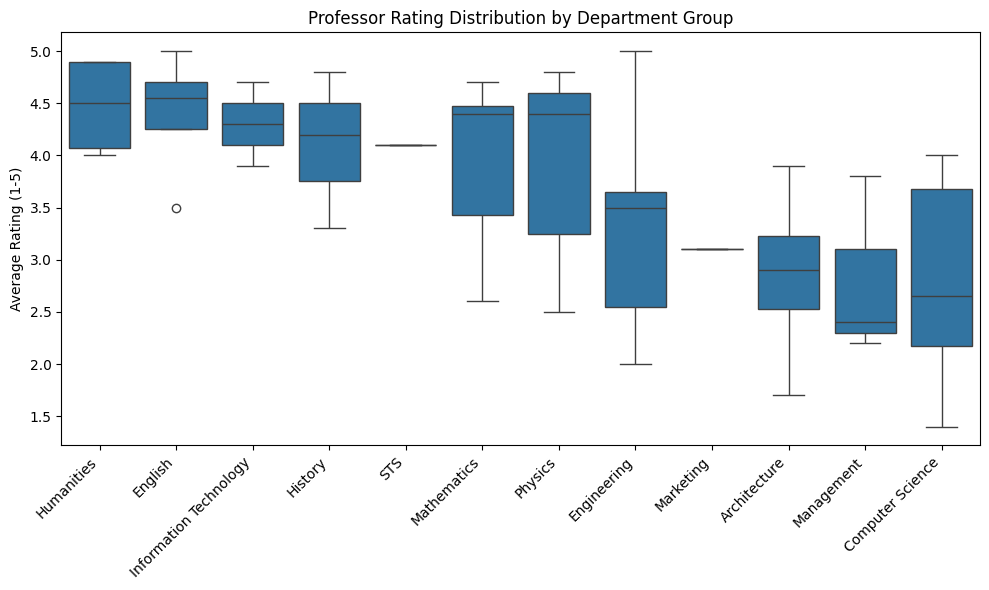


Correlation between difficulty and rating: r = -0.739, p = 0.0000


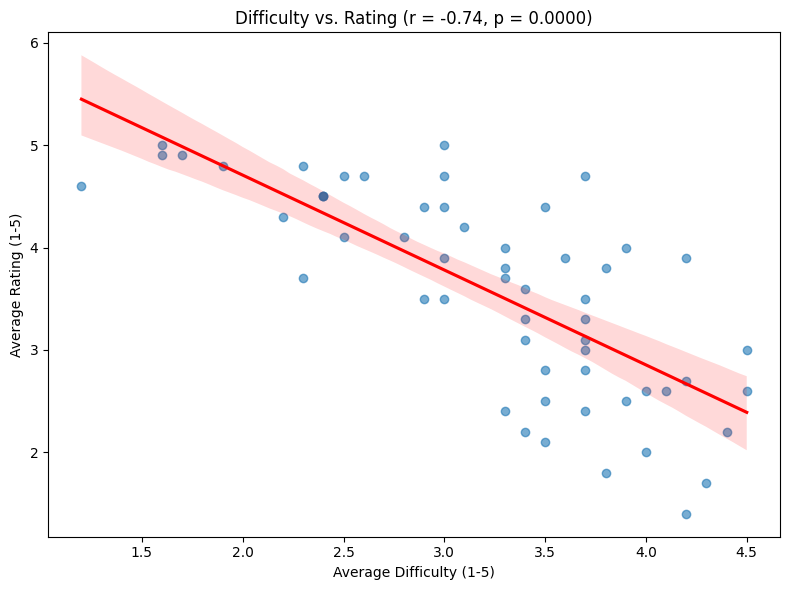

In [83]:
from scipy import stats

# 2a. Does average quality rating differ by department group?
dept_summary = prof_df.groupby("department_group")["avg_rating"].agg(["mean", "std", "count"]).round(2)
dept_summary = dept_summary.sort_values("mean", ascending=False)
print("Average rating by department group:")
print(dept_summary)

plt.figure(figsize=(10, 6))
order = prof_df.groupby("department_group")["avg_rating"].mean().sort_values(ascending=False).index
sns.boxplot(data=prof_df, x="department_group", y="avg_rating", order=order)
plt.xticks(rotation=45, ha="right")
plt.title("Professor Rating Distribution by Department Group")
plt.ylabel("Average Rating (1-5)")
plt.xlabel(None)
plt.tight_layout()
plt.savefig("rating_by_department.png", dpi=300, bbox_inches="tight")
plt.show()

# 2b. Does difficulty predict quality rating?
corr, p_value = stats.pearsonr(prof_df["avg_difficulty"], prof_df["avg_rating"])
print(f"\nCorrelation between difficulty and rating: r = {corr:.3f}, p = {p_value:.4f}")

plt.figure(figsize=(8, 6))
sns.regplot(data=prof_df, x="avg_difficulty", y="avg_rating",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title(f"Difficulty vs. Rating (r = {corr:.2f}, p = {p_value:.4f})")
plt.xlabel("Average Difficulty (1-5)")
plt.ylabel("Average Rating (1-5)")
plt.tight_layout()
plt.savefig("difficulty_vs_rating.png", dpi=300, bbox_inches="tight")
plt.show()

# 2c. Check:

In [84]:
diff_by_dept = prof_df.groupby("department_group")["avg_difficulty"].mean().sort_values(ascending=False)
print(diff_by_dept)

department_group
Architecture              3.975000
Computer Science          3.920000
Engineering               3.445455
Marketing                 3.400000
Mathematics               3.383333
Management                3.333333
Physics                   2.957143
History                   2.900000
Information Technology    2.733333
STS                       2.500000
Humanities                2.350000
English                   2.050000
Name: avg_difficulty, dtype: float64


In [85]:
# Does difficulty still track with rating within CS specifically?
cs_only = prof_df[prof_df["department_group"] == "Computer Science"]
corr_cs, p_cs = stats.pearsonr(cs_only["avg_difficulty"], cs_only["avg_rating"])
print(f"Within Computer Science: r = {corr_cs:.3f}, p = {p_cs:.4f}, n = {len(cs_only)}")

Within Computer Science: r = -0.045, p = 0.9014, n = 10


### Step 3: Sentiment Analysis

In [86]:
# ============================================================================
# STEP 3: Sentiment analysis on review text
# ============================================================================
# Checks whether the TONE of what students write matches their NUMERIC
# rating - a complementary angle to the difficulty/department analysis,
# using the actual review comments already collected in reviews_by_prof.

!pip install vaderSentiment -q

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def avg_sentiment(reviews):
    """Average VADER compound sentiment score across a professor's reviews.
    Compound score ranges from -1 (most negative) to +1 (most positive).
    Reviews with no comment text are skipped."""
    scores = []
    for r in reviews:
        comment = r.get("comment", "")
        if comment and comment.strip():
            scores.append(analyzer.polarity_scores(comment)["compound"])
    if not scores:
        return np.nan
    return np.mean(scores)


# Compute average sentiment per professor, matched back to prof_df by name
sentiment_by_prof = {name: avg_sentiment(reviews) for name, reviews in reviews_by_prof.items()}
prof_df["avg_sentiment"] = prof_df["name"].map(sentiment_by_prof)

print(f"Sentiment computed for {prof_df['avg_sentiment'].notna().sum()} of {len(prof_df)} professors")
prof_df[["name", "department_group", "avg_rating", "avg_sentiment"]].sort_values("avg_sentiment", ascending=False).head(10)

Sentiment computed for 57 of 57 professors


,name,department_group,avg_rating,avg_sentiment
55,Alison Lefkovitz,History,4.8,0.951825
52,Megan O'Neill,Humanities,4.9,0.862855
47,Amber George,Humanities,4.9,0.851986
45,Leli Tyler,English,5.0,0.809150
34,Michel Boufadel,Engineering,5.0,0.777500
12,Padma Natarajan,Mathematics,4.5,0.747244
14,Amitabha Bose,Mathematics,4.7,0.737568
19,Steve Kane,Physics,4.8,0.731893
20,Esmeralda Vataj,Physics,4.7,0.717012
18,Libby Maljian,Physics,4.5,0.661800


Correlation between review sentiment and numeric rating: r = 0.939, p = 0.0000


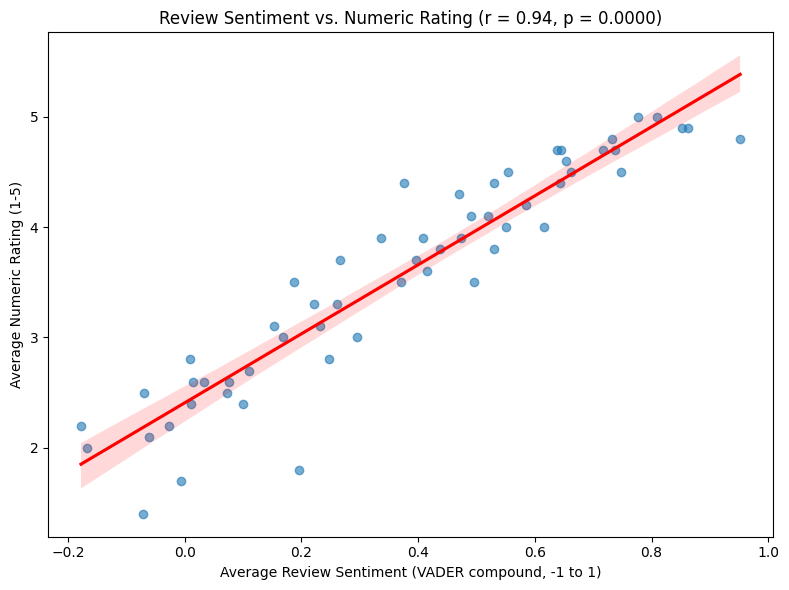

In [87]:
valid_sentiment = prof_df["avg_sentiment"].notna()
corr_sent, p_sent = stats.pearsonr(
    prof_df.loc[valid_sentiment, "avg_sentiment"],
    prof_df.loc[valid_sentiment, "avg_rating"]
)
print(f"Correlation between review sentiment and numeric rating: r = {corr_sent:.3f}, p = {p_sent:.4f}")

plt.figure(figsize=(8, 6))
sns.regplot(data=prof_df, x="avg_sentiment", y="avg_rating",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title(f"Review Sentiment vs. Numeric Rating (r = {corr_sent:.2f}, p = {p_sent:.4f})")
plt.xlabel("Average Review Sentiment (VADER compound, -1 to 1)")
plt.ylabel("Average Numeric Rating (1-5)")
plt.tight_layout()
plt.savefig("sentiment_vs_rating.png", dpi=300, bbox_inches="tight")
plt.show()

### Step 4: Predictive Model

In [88]:
# ============================================================================
# STEP 4: Predictive model - can we estimate a professor's rating from
# difficulty, sentiment, and review volume?
# ============================================================================
# Mirrors the model-benchmarking approach from the Fossil Age project:
# fit a baseline and a couple of alternatives, compare them honestly rather
# than reporting only whichever number looks best.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Build the modeling dataset - drop rows missing any of the three features
model_data = prof_df.dropna(subset=["avg_difficulty", "avg_sentiment", "num_ratings", "avg_rating"]).copy()
print(f"Modeling on {len(model_data)} professors (after dropping missing values)")

X = model_data[["avg_difficulty", "avg_sentiment", "num_ratings"]]
y = model_data["avg_rating"]

# Small dataset (57 rows) - use a train/test split rather than k-fold, and
# treat any result here as a rough estimate, not a robust benchmark. With
# this few data points, the split itself introduces real variance in the
# score you'd get from run to run.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Baseline: predict the mean every time
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

# Model 1: Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)
lin_r2 = r2_score(y_test, lin_pred)
lin_mae = mean_absolute_error(y_test, lin_pred)

# Model 2: Random Forest (captures potential non-linear effects)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print(f"\n{'Model':<20} {'MAE':>8} {'R2':>8}")
print(f"{'Baseline (mean)':<20} {baseline_mae:>8.3f} {'-':>8}")
print(f"{'Linear Regression':<20} {lin_mae:>8.3f} {lin_r2:>8.3f}")
print(f"{'Random Forest':<20} {rf_mae:>8.3f} {rf_r2:>8.3f}")

print("\nLinear regression coefficients:")
for feature, coef in zip(X.columns, lin_model.coef_):
    print(f"  {feature}: {coef:.4f}")

# Random Forest feature importance - which factor matters most?
print("\nRandom Forest feature importance:")
for feature, importance in zip(X.columns, rf_model.feature_importances_):
    print(f"  {feature}: {importance:.3f}")

Modeling on 57 professors (after dropping missing values)

Model                     MAE       R2
Baseline (mean)         1.022        -
Linear Regression       0.258    0.921
Random Forest           0.231    0.935

Linear regression coefficients:
  avg_difficulty: -0.1700
  avg_sentiment: 2.7631
  num_ratings: -0.0004

Random Forest feature importance:
  avg_difficulty: 0.030
  avg_sentiment: 0.931
  num_ratings: 0.039


# Findings: Department Ratings, Difficulty, and Sentiment

**Dataset:** 57 NJIT professors across 12 department groups, built by batch-scraping RateMyProfessor via a custom GraphQL search and scraper, covering ~2,300 individual student reviews.

**1. Department ratings vary substantially, but the gap is mostly explained by difficulty, not department itself.**
Humanities-adjacent fields (Humanities, English, History) average 4.1-4.5 out of 5, while Computer Science, Architecture, and Management average around 2.8, more than a full point lower. But average course difficulty follows almost the exact same ranking in reverse: Architecture (3.98) and Computer Science (3.92) are the hardest-rated departments, while English (2.33) and Humanities (2.35) are the easiest. Overall, difficulty and rating are strongly negatively correlated (r = -0.74, p < 0.0001), suggesting the department effect is largely a difficulty effect in disguise.

**2. That difficulty-rating link doesn't clearly hold up within a single department.**
Within Computer Science specifically (n=10), difficulty and rating show essentially no relationship (r = -0.045, p = 0.90). With only 10 professors per department, this isn't strong evidence the effect disappears, it's more likely the sample is too small to detect it, if it exists. Worth flagging as a genuine limitation rather than treating the null result as conclusive either way.

**3. What students write matches what they click.**
Average review sentiment (via VADER) correlates very strongly with average numeric rating (r = 0.94, p < 0.0001). Professors whose reviews read positively also get high star ratings, and vice versa. The two signals are highly consistent, which is a reasonable validation that the rating system reflects genuine sentiment rather than being an arbitrary or noisy number. (Caveat: VADER is a relatively simple, lexicon-based tool. Part of this strong correlation may come from reviewers who use strongly charged language also being the ones who leave extreme numeric ratings, rather than this proving something deeper about rating psychology.)

**4. A model combining all three features explains ~90% of rating variance - but it's mostly sentiment doing the work.**
A linear regression and a random forest, both trained on difficulty, sentiment, and review count, cut prediction error by about 70% compared to a mean-only baseline (MAE 0.26 vs. 1.022) and reach R² ≈ 0.90. That sounds impressive, but it's largely a restatement of finding #3, not a new independent result: random forest feature importance puts sentiment at 0.94 out of 1.0, with difficulty and review volume contributing almost nothing (0.03 and 0.04 respectively). In other words, sentiment alone is already capturing nearly everything the model needs, adding difficulty and review count barely improves on what sentiment tells you by itself.

## Overall takeaway

Numeric ratings on RateMyProfessor are internally consistent (sentiment and rating agree closely) and strongly tied to course difficulty at the department level, but that department-level pattern is largely a difficulty effect, not necessarily a reflection of teaching quality, and doesn't clearly hold up within a single department at this sample size. A predictive model confirms sentiment is the dominant signal in the data; difficulty and review volume add little once sentiment is known.

## Limitations

- 57 professors across 12 department groups is a small sample, especially per department (as few as 1-3 professors in some groups)
- The within-department correlation check (Computer Science, n=10) is likely underpowered rather than a true null result
- VADER sentiment is a simple, lexicon-based tool - the strong sentiment-rating correlation may partly reflect that emotionally charged language and extreme ratings tend to come from the same reviewers, rather than proving something deeper about how ratings form
- The predictive model was evaluated on a single train/test split given the small dataset size, so the reported R²/MAE should be read as a rough estimate, not a robust benchmark